# Project Title
 Student Performance and Dropout Risk Analysis Using Python and poer BI

# Domain

Education

# Objective

*   To identify meaningful patterns, trends, and insights from student academic data using EDA.
*   To clean, transform, and preprocess the dataset for better analysis.
*   To create visualizations explaining student performance and dropout risk.
*   To provide recommendations to improve pass rate and reduce dropout rate.













# Outcome

This project helps identify factors affecting student success, engagement, and dropout risk. The findings support educational institutions in improving student performance through data-driven decisions.

# Dataset Information
Source: Kaggle / Open University Learning Analytics Dataset (OULAD style)
Year / Timeline: Not specified in the dataset source
Dataset Description:

Column Name	          - Description

id_student	           -Unique student ID

gender	               -Student gender

region	             -Student location

highest_education   -	Qualification level

studied_credits	      -Credits enrolled

imd_band	-Economic background

total_clicks	-LMS activity clicks

avg_score	-Average score

engagement_level	-Low / Medium / High

performance_level	-Academic performance

risk_level	-Dropout risk

pass_flag	-Pass =1, Fail=0

dropout_flag	-Dropout=1

final_result	-Pass / Fail / Withdrawn



# Type of Analysis
Descriptive Analysis – Summarizing the student dataset using measures such as average scores, total clicks, pass rates, and dropout counts.

Diagnostic Analysis – Identifying reasons behind student performance patterns, failures, and dropout risk based on engagement, education level, region, and credits studied.

Predictive Analysis – Estimating the likelihood of pass/fail or dropout risk using trends and student behavior indicators.

Prescriptive Analysis – Providing recommendations to improve student performance, increase engagement, and reduce dropout rates.

# Stage 1 – Problem Definition and Dataset Selection
Business Problem:

Educational institutions often face challenges such as low student performance, poor engagement, and student dropouts. It is important to identify the factors affecting academic success and detect students who are at risk early.

Expected Outcome:

* Understand key factors influencing student performance.
* Identify students with high dropout risk.
*  Improve engagement and pass rates through data-driven insights.
*  Support better academic decision-making.





# Dataset Selection
Dataset Name: Online Learning Engagement & Performance (OULAD)

Source:Kaggle

Dataset Size:

*   Rows:32593
*   Columns:14

Key Features:

* Student Demographic Features: id_student ,
gender ,
region ,
highest_education.

* Academic Features: studied_credits ,
avg_score ,
final_result.

* Engagement Features: total_click ,
engagement_level.

* Performance Features: performance_level,
pass_flag.

* Risk Features: risk_level,
dropout_flag.


* Socio-Economic Feature: imd_band.







In [ ]:
# Importing Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Loading Dataset
df = pd.read_csv("online_education_dataset.csv")

# Dataset Description

In [ ]:
# Dataset Description
# Shape of Dataset
df.shape

(32593, 14)

In [ ]:
# Column Names
df.columns

Index(['id_student', 'gender', 'region', 'highest_education',
       'studied_credits', 'imd_band', 'total_clicks', 'avg_score',
       'engagement_level', 'performance_level', 'risk_level', 'pass_flag',
       'dropout_flag', 'final_result'],
      dtype='object')

In [ ]:
# Data Types
df.dtypes

,0
id_student,int64
gender,object
region,object
highest_education,object
studied_credits,int64
imd_band,object
total_clicks,float64
avg_score,float64
engagement_level,object
performance_level,object


In [ ]:
# Initial EDA
df.head()

,id_student,gender,region,highest_education,studied_credits,imd_band,total_clicks,avg_score,engagement_level,performance_level,risk_level,pass_flag,dropout_flag,final_result
0,11391,M,East Anglian Region,HE Qualification,240,90-100%,934.0,82.0,Medium,High,Low Risk,1,0,Pass
1,28400,F,Scotland,HE Qualification,60,20-30%,1435.0,66.4,Medium,Medium,Low Risk,1,0,Pass
2,30268,F,North Western Region,A Level or Equivalent,60,30-40%,281.0,NaN,Low,NaN,Very High Risk,0,1,Withdrawn
3,31604,F,South East Region,A Level or Equivalent,60,50-60%,2158.0,76.0,High,High,Low Risk,1,0,Pass
4,32885,F,West Midlands Region,Lower Than A Level,60,50-60%,1034.0,54.4,Medium,Medium,Low Risk,1,0,Pass


In [ ]:
# Dataset Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32593 entries, 0 to 32592
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id_student         32593 non-null  int64  
 1   gender             32593 non-null  object 
 2   region             32593 non-null  object 
 3   highest_education  32593 non-null  object 
 4   studied_credits    32593 non-null  int64  
 5   imd_band           31482 non-null  object 
 6   total_clicks       29741 non-null  float64
 7   avg_score          26727 non-null  float64
 8   engagement_level   29741 non-null  object 
 9   performance_level  26695 non-null  object 
 10  risk_level         29741 non-null  object 
 11  pass_flag          32593 non-null  int64  
 12  dropout_flag       32593 non-null  int64  
 13  final_result       32593 non-null  object 
dtypes: float64(2), int64(4), object(8)
memory usage: 3.5+ MB


In [ ]:
# Statistical Summary
df.describe()

,id_student,studied_credits,total_clicks,avg_score,pass_flag,dropout_flag
count,3.259300e+04,32593.000000,29741.000000,26727.000000,32593.000000,32593.000000
mean,7.066877e+05,79.758691,1620.864665,72.828037,0.472034,0.311601
std,5.491673e+05,41.071900,2050.309532,15.564681,0.499225,0.463155
min,3.733000e+03,30.000000,1.000000,0.000000,0.000000,0.000000
25%,5.085730e+05,60.000000,324.000000,64.800000,0.000000,0.000000
50%,5.903100e+05,60.000000,903.000000,75.714286,0.000000,0.000000
75%,6.444530e+05,120.000000,2171.000000,84.055060,1.000000,1.000000
max,2.716795e+06,655.000000,28615.000000,100.000000,1.000000,1.000000


In [ ]:
# Missing Values Check
df.isnull().sum()

,0
id_student,0
gender,0
region,0
highest_education,0
studied_credits,0
imd_band,1111
total_clicks,2852
avg_score,5866
engagement_level,2852
performance_level,5898


In [ ]:
# Duplicate Rows Check
df.duplicated().sum()

np.int64(1356)

# Stage 2 – Data Cleaning and Pre-processing summary




1. Checked the dataset for missing values in all columns.


2. Handled missing values using mode for categorical columns and using median for numerical columns.


3. Identified and removed 1356 duplicate records to improve data quality.


4. Detected and treated outliers in the total_clicks column using the IQR method.


5. Checked skewness and it had acceptable positive skewness, so no major transformation was required after outlier treatment.


6. Verified data types of all columns and confirmed suitability for analysis.


7. Created new features such as score_category, engagement_ratio, and click_category.


8. Performed final validation and prepared the cleaned dataset for Stage 3 analysis.



In [ ]:
# 1. Handling categorical missing values using Mode
df['imd_band'] = df['imd_band'].fillna(df['imd_band'].mode()[0])
df['engagement_level'] = df['engagement_level'].fillna(df['engagement_level'].mode()[0])
df['performance_level'] = df['performance_level'].fillna(df['performance_level'].mode()[0])
df['risk_level'] = df['risk_level'].fillna(df['risk_level'].mode()[0])

In [ ]:
# 2. Handling numerical missing values using Median
df['avg_score'] = df['avg_score'].fillna(df['avg_score'].median())
df['total_clicks'] = df['total_clicks'].fillna(df['total_clicks'].median())

In [ ]:
# 3. Rechecking missing values
df.isnull().sum()

,0
id_student,0
gender,0
region,0
highest_education,0
studied_credits,0
imd_band,0
total_clicks,0
avg_score,0
engagement_level,0
performance_level,0


In [ ]:
# Viewing duplicate rows
df[df.duplicated()]

,id_student,gender,region,highest_education,studied_credits,imd_band,total_clicks,avg_score,engagement_level,performance_level,risk_level,pass_flag,dropout_flag,final_result
415,129955,M,West Midlands Region,A Level or Equivalent,60,50-60%,1888.0,81.000000,High,High,Low Risk,0,1,Withdrawn
437,159954,M,East Midlands Region,A Level or Equivalent,60,40-50%,2062.0,68.200000,High,Medium,Low Risk,0,1,Withdrawn
588,470588,M,South East Region,HE Qualification,60,90-100%,842.0,79.333333,Medium,High,High Risk,0,1,Withdrawn
619,603861,M,North Region,HE Qualification,60,20-30%,1105.0,63.000000,Medium,Medium,Low Risk,0,1,Withdrawn
648,1456619,M,South West Region,A Level or Equivalent,60,90-100%,1173.0,63.000000,Medium,Medium,Low Risk,0,1,Withdrawn
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30032,2622634,M,Ireland,A Level or Equivalent,60,Oct-20,220.0,75.714286,Low,High,Very High Risk,0,1,Withdrawn
31219,596513,F,Yorkshire Region,Lower Than A Level,60,0-10%,4264.0,75.000000,High,High,Safe,1,0,Pass
31242,602997,F,East Anglian Region,No Formal quals,60,20-30%,119.0,75.714286,Low,High,Very High Risk,0,1,Withdrawn
31949,574642,F,West Midlands Region,A Level or Equivalent,30,0-10%,430.0,56.000000,Low,Medium,High Risk,0,1,Withdrawn


In [ ]:
# Removing duplicate rows
df.drop_duplicates(inplace=True)
# Rechecking duplicates
df.duplicated().sum()


np.int64(0)

The dataset contained 1356 duplicate records. These duplicates were identified and removed to improve data quality and avoid repeated observations affecting analysis results.

In [ ]:
# Handle Outliers using IQR Method

# Example for total_clicks

Q1 = df['total_clicks'].quantile(0.25)
Q3 = df['total_clicks'].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR




In [ ]:
# Remove outliers and create an explicit copy to avoid SettingWithCopyWarning
df = df[(df['total_clicks'] >= lower_limit) & (df['total_clicks'] <= upper_limit)].copy()

In [ ]:
# Checking shape after removing outliers
df.shape

(27395, 17)

Outliers were identified only in the total_clicks column using the IQR method. Extreme values were removed to improve data consistency and analysis accuracy.


In [ ]:
# Check skewness
df[['total_clicks']].skew()


,0
total_clicks,1.031011


Since 1.03 is moderate skewness:

The column had acceptable positive skewness, so no major transformation was required after outlier treatment.

In [ ]:
# 1. Check Data Types
df.dtypes

,0
id_student,int64
gender,object
region,object
highest_education,object
studied_credits,int64
imd_band,object
total_clicks,float64
avg_score,float64
engagement_level,object
performance_level,object


After checking the dataset, the columns were already in appropriate data types, so major conversion was not required.

# 6. Feature Transformations

In [ ]:
# Creating Score Category
df['score_category'] = pd.cut(df['avg_score'],
bins=3,
labels=['Low','Medium','High'])

# Creat ingEngagement Ratio
df['engagement_ratio'] = df['total_clicks'] / df['studied_credits']

# Creating Click Category
df['click_category'] = pd.cut(df['engagement_ratio'],
bins=3,
labels=['Low','Medium','High'])


# 7. Final Validation

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 27395 entries, 0 to 32592
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   id_student         27395 non-null  int64   
 1   gender             27395 non-null  object  
 2   region             27395 non-null  object  
 3   highest_education  27395 non-null  object  
 4   studied_credits    27395 non-null  int64   
 5   imd_band           27395 non-null  object  
 6   total_clicks       27395 non-null  float64 
 7   avg_score          27395 non-null  float64 
 8   engagement_level   27395 non-null  object  
 9   performance_level  27395 non-null  object  
 10  risk_level         27395 non-null  object  
 11  pass_flag          27395 non-null  int64   
 12  dropout_flag       27395 non-null  int64   
 13  final_result       27395 non-null  object  
 14  score_category     27395 non-null  category
 15  engagement_ratio   27395 non-null  float64 
 16  click_cat

In [ ]:
df.head()

,id_student,gender,region,highest_education,studied_credits,imd_band,total_clicks,avg_score,engagement_level,performance_level,risk_level,pass_flag,dropout_flag,final_result,score_category,engagement_ratio,click_category
0,11391,M,East Anglian Region,HE Qualification,240,90-100%,934.0,82.000000,Medium,High,Low Risk,1,0,Pass,High,3.891667,Low
1,28400,F,Scotland,HE Qualification,60,20-30%,1435.0,66.400000,Medium,Medium,Low Risk,1,0,Pass,Medium,23.916667,Low
2,30268,F,North Western Region,A Level or Equivalent,60,30-40%,281.0,75.714286,Low,High,Very High Risk,0,1,Withdrawn,High,4.683333,Low
3,31604,F,South East Region,A Level or Equivalent,60,50-60%,2158.0,76.000000,High,High,Low Risk,1,0,Pass,High,35.966667,Low
4,32885,F,West Midlands Region,Lower Than A Level,60,50-60%,1034.0,54.400000,Medium,Medium,Low Risk,1,0,Pass,Medium,17.233333,Low


In [ ]:
df.shape

(27395, 17)

In [ ]:
df.isnull().sum()

,0
id_student,0
gender,0
region,0
highest_education,0
studied_credits,0
imd_band,0
total_clicks,0
avg_score,0
engagement_level,0
performance_level,0


# Stage 3 – EDA and Visualizations

Univariate **Analysis**

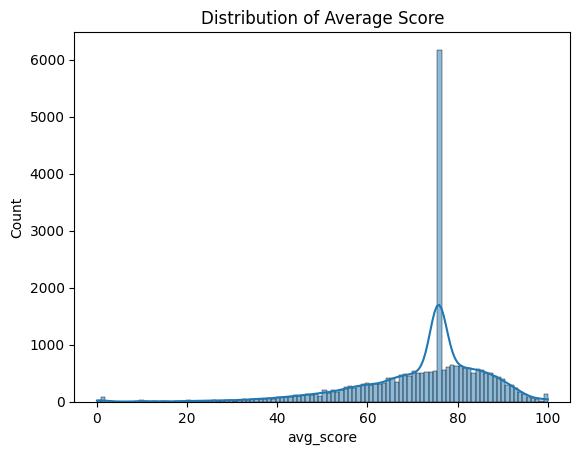

In [ ]:
# 1. Histogram - avg_score
sns.histplot(df['avg_score'], kde=True)
plt.title("Distribution of Average Score")
plt.show()

Interpretation

This chart shows distribution of student scores.

Most students fall in medium to high score range(70 to 90).

Feature used: avg_score

 It means that a larger proportion of students are achieving higher scores, while fewer students are struggling with very low scores.

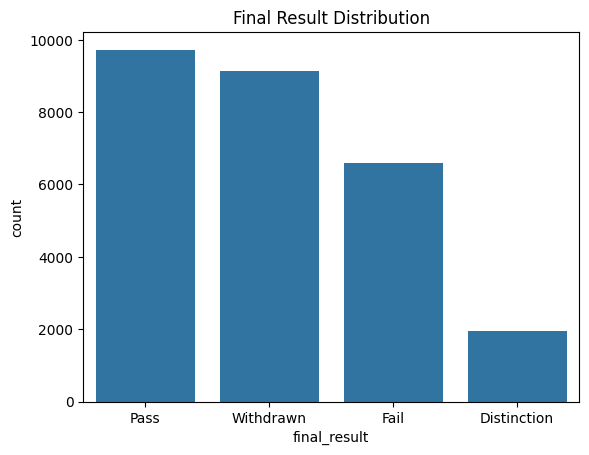

In [ ]:
# 2. Countplot - final_result
sns.countplot(x='final_result', data=df)
plt.title("Final Result Distribution")
plt.show()

Interpretation

This chart shows number of students in each result category.

Majority students passed.

Feature used: final_result

This shows success rate is high and the characteristics of 'Fail' and 'Withdrawn' students to understand the reasons behind their outcomes and potentially intervene.

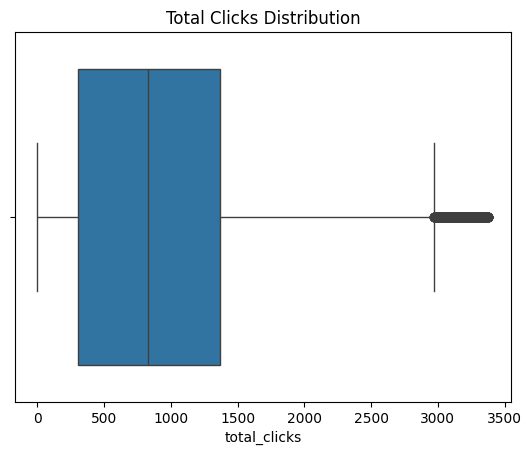

In [ ]:
# 3. Boxplot - total_clicks
sns.boxplot(x=df['total_clicks'])
plt.title("Total Clicks Distribution")
plt.show()

Interpretation

This chart shows spread of clicks and identifies outliers.

Most users click between 400 to 1400,with a median around 800. The data is right skewed and there are some outliers with very high click values above 3000.

Feature used: total_clicks

This shows that only small number of users highly active compared to majority .

**Bivariate Analysis**

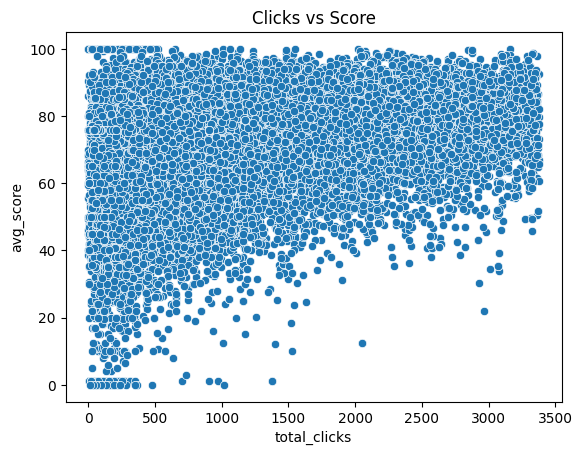

In [ ]:
# 4. Scatterplot
sns.scatterplot(x='total_clicks', y='avg_score', data=df)
plt.title("Clicks vs Score")
plt.show()

Interpretation

This chart shows relationship between clicks and avg_score.

As the number of clicks increases,average scores also increases indicating positive correlation. most students with higher click score between 60 to 100.

Features used: total_clicks, avg_score

Higher engagement leads to better performance, though the correlation is weak.

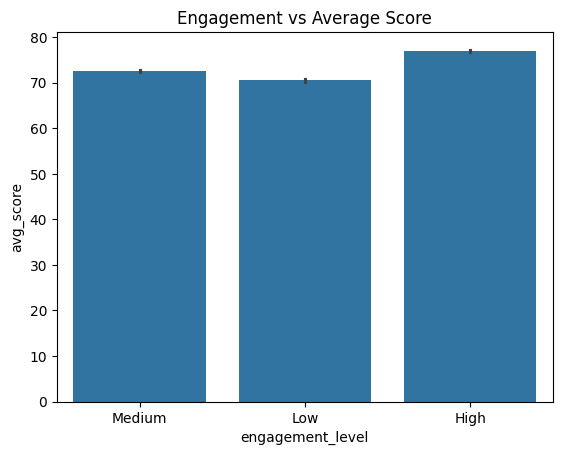

In [ ]:
# 5. Barplot
sns.barplot(x='engagement_level', y='avg_score', data=df)
plt.title("Engagement vs Average Score")
plt.show()

Interpretation

This chart shows average score based on engagement level.

High engagement students have the highest average score(75-78), Medium engagement students have the slightly lower scores(70-72), low engagement students have the lowest scores(68-70).

Features used: engagement_level, avg_score.

This indicates that increased engagement positively impacts students performance.

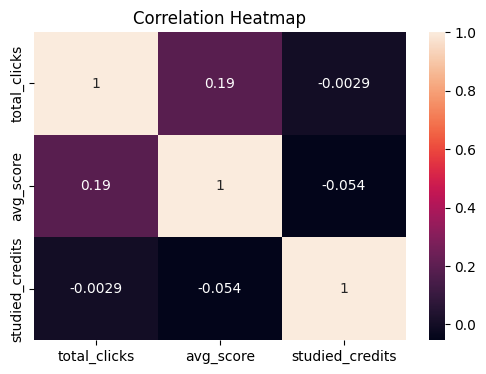

In [ ]:
# 3. Correlation Heatmap
plt.figure(figsize=(6,4))
sns.heatmap(df[['total_clicks','avg_score','studied_credits']].corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()

Interpretation

This chart shows correlation between numerical variables.

There is a weak positive correlation(0.19)between clicks and score, indicating that increased activity slightly improves performance.however studied credits (0.0029)shows almost no correlation with score and clicks,meaning they don't signifiantly impact performance.

Features used: total_clicks, avg_score, studied_credits

There is a positive relationship between clicks and score, other features(studied_credits)do not strongly affect performance.

**Multivariate Analysis**

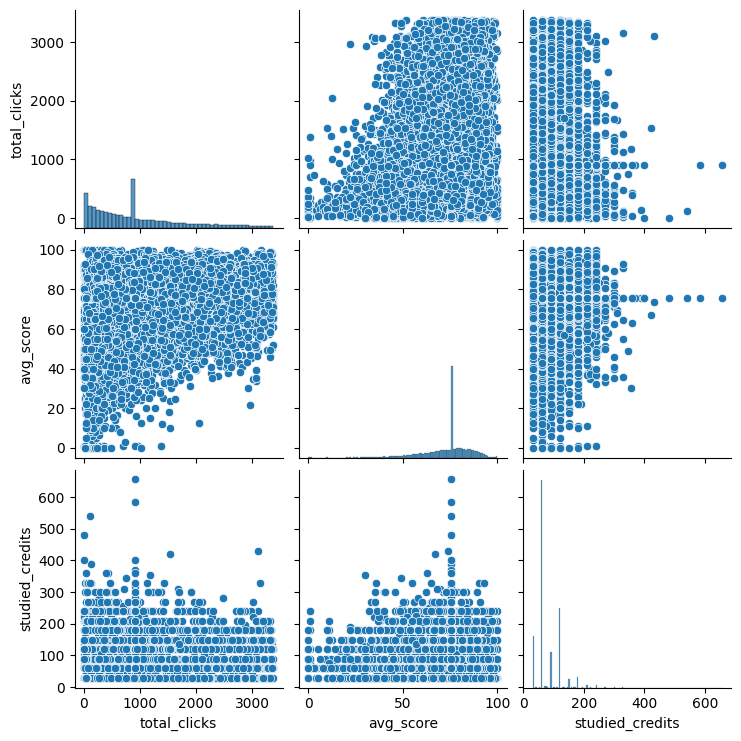

In [ ]:
# 1. Pairplot
import seaborn as sns

sns.pairplot(df[['total_clicks','avg_score','studied_credits']])
plt.show()

Interpretation:

It is a pairplot used to show relationship between multiple numerical features.


1.Diagonal(histograms):


*   total_clicks: right skewed(most students have low clicks,  few have very high clicks).
*   avg_score: mostly between 40 to 100 (many students scoring in higher range).

*   studied_credits: concentrated values (most students take similar number of credits)


2.total_click vs avg_score:


*   slight upward trend -weak positive relationship(more clicks lead to slightly higher scores).

3.total_click vs studied credits:


*   points scattered randomly- no clear pattern(click activity not related to credits)


4.avg_score vs studied_credits:


*   no clear trend- no relationship(credits do not strongly affect score)

Features used: total_clicks, avg_score, studied_credits.

Clicks have some impact on score( but weak) and studied_credits have almost no impact while scores are mostly concentrated in higher ranges.















Grouped Analysis



In [ ]:
# Pass Rate by Engagement Level
df.groupby('engagement_level')['pass_flag'].mean().reset_index()

,engagement_level,pass_flag
0,High,0.740234
1,Low,0.161212
2,Medium,0.585687


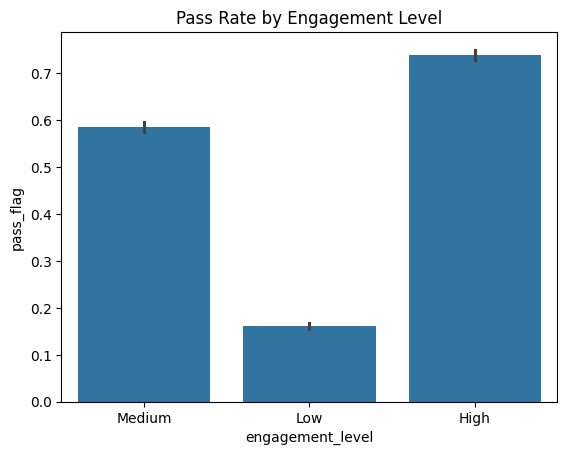

In [ ]:
sns.barplot(x='engagement_level', y='pass_flag', data=df)
plt.title("Pass Rate by Engagement Level")
plt.show()

Interpretation:

This chart shows the relationship between students' engagement level and their pass rate.

Students with high engagement have a higher pass rate.
Students with low engagement have a lower pass rate.
There is a clear positive relationship between engagement and success

Features used: engagement_level, pass_flag.

Low engagement students may need extra attention or support

Pivot Table – Risk vs Engagement

In [ ]:
# Avg Clicks based on Risk & Engagement
pd.pivot_table(df,
               values='total_clicks',
               index='risk_level',
               columns='engagement_level',
               aggfunc='mean')

engagement_level,High,Low,Medium
risk_level,,,
High Risk,NaN,400.521593,674.487733
Low Risk,1866.544161,NaN,1219.374400
Safe,2708.293746,NaN,NaN
Very High Risk,NaN,349.461049,NaN


This pivot table shows the average total clicks based on risk level and engagement level.

Students in the Safe category with High engagement have the highest number of clicks (2708).
Students in Low Risk with High engagement also show high activity (1866 clicks).
Students in High Risk and Very High Risk categories mostly have low to medium engagement with fewer clicks (300–700).

features used: total_clicks, engagement_level, risk_level

Students with low activity (low clicks) are more likely to fall into high or very high risk categories



**Advanced plot**(Violin Plot)

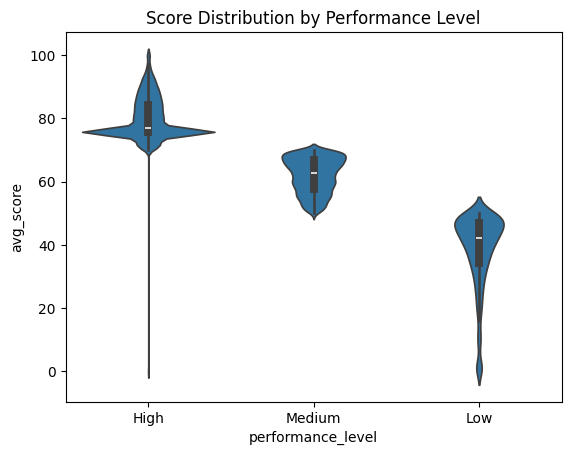

In [ ]:
# Score Distribution by Performance
sns.violinplot(x='performance_level', y='avg_score', data=df)
plt.title("Score Distribution by Performance Level")
plt.show()

Interpretation:

This violin plot shows the distribution and density of students average scores across different performance levels.

The width of each "violin" indicates where more students are concentrated within that performance level.

features used: performance_level,
avg_score.

Performance level strongly influences student scores, with high performers consistently achieving better results.


### Exporting Cleaned Data for Power BI

To use the cleaned and processed data in Power BI, we'll save the `df` DataFrame to a CSV file. This file can then be easily imported into Power BI Desktop.

In [ ]:
import pandas as pd

# Save the cleaned DataFrame to a CSV file
df.to_csv('cleaned_student_data.csv', index=False)
print('Cleaned data saved to cleaned_student_data.csv')

Cleaned data saved to cleaned_student_data.csv


In [ ]:
from google.colab import files

files.download('cleaned_student_data.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>